# Clase 02: Listas, conjuntos, diccionarios y eficiencia

Pregunta guía:

> ¿Cómo podemos observar que una estructura de datos es mejor que otra para cierta operación?

Idea central:

> No existe una estructura de datos mejor en absoluto. Existe una estructura más adecuada para ciertas operaciones.

## Objetivos

Al terminar este notebook podrás:

- Medir tiempos de ejecución en Python.
- Comparar búsqueda en `list` y `set`.
- Usar `dict` para contar frecuencias.
- Usar `collections.Counter`.
- Entender informalmente `O(1)`, `O(n)` y `O(n²)`.
- Explicar qué operación quieres hacer eficiente al elegir una estructura de datos.

## 1. Preparación

Esta celda carga el módulo auxiliar de la clase. Funciona si abres el notebook desde `clase_02/` o desde la carpeta principal del repositorio.

In [6]:
from pathlib import Path
import sys
import time
from collections import Counter

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_02']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    comparar_busquedas_por_tamano,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print(f'Material cargado desde: {raiz}')

Material cargado desde: c:\Users\0286945\Documents\GitHub\EstructurasDatos\clase_02


## 2. Una primera medición con `time.perf_counter`

`time.perf_counter` permite medir intervalos cortos de tiempo. La idea básica es tomar una marca antes, ejecutar la operación y tomar otra marca después.

In [7]:
datos_pequenos = generar_datos(20)
objetivo = -1

inicio = time.perf_counter()
resultado = objetivo in datos_pequenos
fin = time.perf_counter()

print(f'Datos: {datos_pequenos}')
print(f'¿Aparece {objetivo}? {resultado}')
print(f'Tiempo medido: {fin - inicio:.10f} segundos')

Datos: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9, 6, 0, 0, 1, 3, 3, 8, 9, 0, 8]
¿Aparece -1? False
Tiempo medido: 0.0000416000 segundos


### Pregunta

¿Por qué una medición tan pequeña puede variar si ejecutas la celda varias veces?

## 3. Función `medir_tiempo`

Usaremos una función que ejecuta varias veces una operación y regresa el tiempo promedio. Esta es la versión base que también aparece en la presentación.

In [8]:
def medir_tiempo_base(funcion, repeticiones=10):
    tiempos = []

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)

    return sum(tiempos) / len(tiempos)


tiempo = medir_tiempo_base(lambda: objetivo in datos_pequenos, repeticiones=10)
print(f'Tiempo promedio: {tiempo:.10f} segundos')

Tiempo promedio: 0.0000005200 segundos


## 4. Búsqueda en `list`

Una lista mantiene orden y repeticiones. Para saber si un valor aparece, Python puede tener que revisar muchos elementos.

In [33]:
n = 100_000
datos = generar_datos(n)
objetivo_presente = datos[-1]
objetivo_ausente = -1

tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)
tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista con {n:,} elementos')
print(f'Objetivo presente: {tiempo_lista_presente:.8f} segundos')
print(f'Objetivo ausente:  {tiempo_lista_ausente:.8f} segundos')

Lista con 100,000 elementos
Objetivo presente: 0.00002995 segundos
Objetivo ausente:  0.00058882 segundos


### Pregunta

Cuando el objetivo está ausente, ¿qué tiene que ocurrir antes de que Python pueda responder `False`?
Tiene que recorrer todos los elementos uno por uno y determinar que no son el buscado.

## 5. Búsqueda en `set`

Un conjunto está diseñado para pertenencia. El costo promedio de preguntar `x in conjunto` suele comportarse como aproximadamente constante respecto al tamaño.

In [10]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)
tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Tamaño de la lista:    {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')
print(f'Set, objetivo presente: {tiempo_set_presente:.10f} segundos')
print(f'Set, objetivo ausente:  {tiempo_set_ausente:.10f} segundos')

Tamaño de la lista:    100,000
Tamaño del conjunto: 10,000
Set, objetivo presente: 0.0000006800 segundos
Set, objetivo ausente:  0.0000002400 segundos


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista? Porque la lista admite repeticiones y el conjunto no.
2. ¿Qué sacrificios tiene usar un `set` si la lista original tenía orden y duplicados? Perder órden y repeteciones.
3. ¿Para qué operación parece más adecuado el conjunto? Para búsquedas de elementos

## 6. Comparar varios tamaños

Ahora compararemos búsqueda de un valor ausente con varios tamaños de entrada. El objetivo ausente ayuda a observar el costo de revisar toda la lista.

In [40]:
tamanos = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000]
resultados = comparar_busquedas_por_tamano(tamanos, repeticiones=8)

print('tamaño      lista (s)       set (s)')
for fila in resultados:
    print(f"{fila['tamano']:>7,}   {fila['tiempo_lista']:>11.8f}   {fila['tiempo_conjunto']:>11.8f}")

tamaño      lista (s)       set (s)
  1,000    0.00000761    0.00000025
  5,000    0.00005829    0.00000019
 10,000    0.00011157    0.00000032
 50,000    0.00036426    0.00000029
100,000    0.00069576    0.00000034
200,000    0.00121959    0.00000027


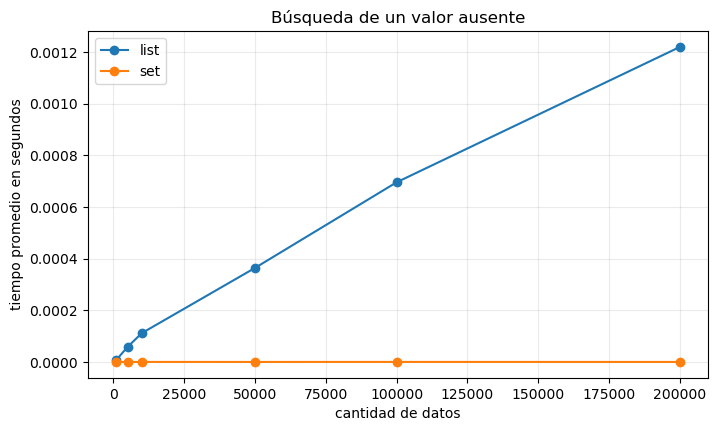

In [41]:
xs = [fila['tamano'] for fila in resultados]
ys_lista = [fila['tiempo_lista'] for fila in resultados]
ys_set = [fila['tiempo_conjunto'] for fila in resultados]

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys_lista, marker='o', label='list')
plt.plot(xs, ys_set, marker='o', label='set')
#plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Responde:

1. ¿Cuál fue más rápido? El set
2. ¿La diferencia crece con el tamaño? Si, bastante rápido
3. ¿Qué estructura usarías si necesitas muchas búsquedas? El set definitivamente. En clase vimos como el set asocia un hash a cada elemento, lo que ahorra la tarea de iterar en cada elementp y ver si es o no es el que buscamos.
4. ¿Contamos aquí el costo de construir el conjunto? ¿Por qué importa esa pregunta? No, pero la pregunta importa porque la construcción del conjunto requiere más operaciones. Si quisieramos considerarlo, tendríamos que adentrarnos a ver las operaciones de generar_datos que a su vez usa la clase Random.
Para fines de esta práctica en realidad estamos viendo a listas y conjuntos como ya dados.

## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

In [42]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 8 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:8]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 8 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4


## 8. Conteo con `Counter`

`Counter` es una herramienta especializada de Python para contar ocurrencias.

In [43]:
conteos_counter = contar_con_counter(datos)

print('Los 8 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(8):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter representan las mismas frecuencias.')

Los 8 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
El diccionario y Counter representan las mismas frecuencias.


## 9. Comparar tiempos de conteo

La diferencia no siempre será enorme. Aquí también nos interesa la claridad de la representación.

In [44]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.8f} segundos')
print(f'Counter:            {tiempo_counter:.8f} segundos')

Diccionario manual: 0.00782770 segundos
Counter:            0.00306634 segundos


### Preguntas

1. ¿Qué hace más explícito el diccionario manual? Va asignando parejas en llave-valor como num-frecuencia y por cada vez que aparece suma uno al valor que es la frecuencia.
2. ¿Qué hace más cómodo `Counter`? Hace lo mismo con cualquier iterable y al ser una clase tiene métodos para devolver los más comunes u otros datos útiles.
3. ¿Qué estructura usarías si necesitas contar frecuencias en un texto o una simulación? Counter

## 10. Complejidad intuitiva

Big-O describe cómo crece el costo cuando crece el tamaño de los datos. No es una medición exacta en segundos.

| Notación | Intuición | Ejemplo |
| --- | --- | --- |
| `O(1)` | aproximadamente constante | acceder a `datos[0]` |
| `O(n)` | proporcional al tamaño | recorrer una lista |
| `O(n²)` | doble recorrido | comparar todos contra todos |

In [45]:
def ejemplo_constante(datos):
    return datos[0]


def ejemplo_lineal(datos, objetivo):
    for dato in datos:
        if dato == objetivo:
            return True
    return False


def ejemplo_cuadratico(datos):
    total = 0
    for a in datos:
        for b in datos:
            total += a == b
    return total


muestra = generar_datos(200)
print(ejemplo_constante(muestra))
print(ejemplo_lineal(muestra, -1))
print(ejemplo_cuadratico(muestra[:60]))

3
False
226


In [50]:
# Grafica extra
objetivo = -1
checador = datos[-1]
def graficar_complejidad(fx=buscar_en_lista, tamanos=[100, 500, 1000, 2000],repeticiones=10):
    t = []
    for elem in tamanos:
        datos = generar_datos(elem)
        tiempo = medir_tiempo(lambda: fx(datos), repeticiones=repeticiones)
        t.append(tiempo)
    plt.figure(figsize=(8, 4.5))
    plt.plot(tamanos, t, marker='o')
    plt.xlabel('cantidad de datos')
    plt.ylabel('tiempo promedio en segundos')
    plt.title(f'Complejidad de {fx.__name__}')
    plt.grid(True, which='both', alpha=0.25)
    plt.show()


In [52]:
#Caso de uso
graficar_complejidad(buscar_en_lista(), tamanos=[100, 500, 1000, 2000], repeticiones=10)

TypeError: buscar_en_lista() missing 2 required positional arguments: 'datos' and 'objetivo'

### Ejercicio

Clasifica los tres ejemplos anteriores como `O(1)`, `O(n)` u `O(n²)` y escribe una justificación breve para cada uno.

## 11. Ejercicio para completar

Cambia los tamaños y repeticiones. Observa si tu conclusión se mantiene.

In [17]:
# Puedes modificar estos valores.
tamanos_ejercicio = [2_000, 20_000, 80_000]
repeticiones_ejercicio = 6

resultados_ejercicio = comparar_busquedas_por_tamano(
    tamanos_ejercicio,
    repeticiones=repeticiones_ejercicio,
)

for fila in resultados_ejercicio:
    print(fila)

{'tamano': 2000, 'tiempo_lista': 1.5283332989686944e-05, 'tiempo_conjunto': 2.3333268472924829e-07}
{'tamano': 20000, 'tiempo_lista': 0.0001453333334211493, 'tiempo_conjunto': 2.3333329105904946e-07}
{'tamano': 80000, 'tiempo_lista': 0.00047171666665235534, 'tiempo_conjunto': 3.166666526036958e-07}


Escribe aquí tu conclusión:

- Estructura que usaría para muchas búsquedas:
- Razón:
- Sacrificio posible:

## 12. Actividad de proyecto / GitHub

Elige o crea uno de estos issues:

- `[DOC] Escribir guía de estilo`
- `[DOC] Documentar flujo básico de GitHub`
- `[TEST] Crear primera prueba de ejemplo`
- `[PROY] Definir estructura inicial de src/`

Flujo esperado:

`Issue → Branch → Commit → Pull Request → Review → Merge`

No trabajes directamente sobre `main`.

## 13. Reflexión final

Responde:

1. ¿Cuál fue más rápido: `list` o `set` para pertenencia?
2. ¿La diferencia crece con el tamaño?
3. ¿Qué estructura usarías si necesitas muchas búsquedas?
4. ¿Qué estructura usarías si necesitas contar frecuencias?
5. ¿Qué sacrificios tiene usar un `set` en lugar de una `list`?
6. ¿Qué aprendiste al medir en lugar de solo razonar?

## 14. Reto opcional

La búsqueda en `set` es rápida, pero construir el `set` también cuesta. Mide el costo total de:

1. Construir el conjunto.
2. Hacer muchas búsquedas.

Pregunta: ¿a partir de cuántas búsquedas empieza a convenir construir el conjunto?

In [18]:
def tiempo_consultas_lista(datos, consultas):
    inicio = time.perf_counter()
    for consulta in consultas:
        consulta in datos
    return time.perf_counter() - inicio


def tiempo_construir_set_y_consultar(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for consulta in consultas:
        consulta in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad in [1, 10, 50, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad)]
    t_lista = tiempo_consultas_lista(datos_reto, consultas)
    t_set_total = tiempo_construir_set_y_consultar(datos_reto, consultas)
    print(f'{cantidad:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set_total:.5f}s')

    1 consultas | lista: 0.00019s | set total: 0.00035s
   10 consultas | lista: 0.00228s | set total: 0.00040s
   50 consultas | lista: 0.00960s | set total: 0.00034s
  100 consultas | lista: 0.01887s | set total: 0.00034s
  500 consultas | lista: 0.10115s | set total: 0.00036s
1,000 consultas | lista: 0.20090s | set total: 0.00038s
